In [1]:
import numpy as np
import pandas as pd
import matlab.engine
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

eng = matlab.engine.start_matlab()

In [5]:
def shell_radii(fractions, R):
    """
    Computes cumulative radii of a multilayer system.
    Model: r_i = R * (x_i)^(1/3)
    where x_i is the cumulative sum of fractions.
    """
    x = np.cumsum(fractions) #cumulative sum
    r = R * np.cbrt(x) #cube root
    return r

def mono_exp(x, TB):
    return 1 - np.exp(-x / TB)  # beta = 1

def fit_mono(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values 
    popt, _ = curve_fit(mono_exp, t, y, bounds=([0], [np.inf]))
    TB = popt[0]
    yfit = mono_exp(t, *popt)
    return pd.Series({"TB": TB, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def stretched_exp(x, TB, beta):
    return 1 - np.exp(-(x / TB) ** beta)

def fit_stretched(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values
    popt, _ = curve_fit(stretched_exp, t, y,bounds=([0, 0], [np.inf, np.inf]))
    TB, beta = popt
    yfit = stretched_exp(t, *popt)
    return pd.Series({"TB": TB, "beta" : beta, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def r2(y, yfit):
    ss_res = np.sum((y - yfit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot 

R = 0.05 #radius of LNP in um
compounds =  ["mRNA", "lipid"]
distrib = np.array([0.1, 0.9])

## defining models

In [6]:
rows = []

rows.append((0, 1, 1, 1, 0))
rows.append((0, 1, 2, 1, 0))
rows.append((0, 2, 1, 0, 1))
rows.append((0, 2, 2, 0, 1))

rows.append((1, 1, 1, 1, 0))
rows.append((1, 1, 2, 0, 1))
rows.append((1, 2, 1, 0, 1))
rows.append((1, 2, 2, 0, 1))

models = pd.DataFrame(rows, columns=["model","shell", "side", "mRNA", "lipid"]).set_index(["model", "shell", "side"])
id_models = models.index.get_level_values("model").unique()
index = models.index.names
models

mRNA  lipid
model shell side             
0     1     1        1      0
            2        1      0
      2     1        0      1
            2        0      1
1     1     1        1      0
            2        0      1
      2     1        0      1
            2        0      1

In [19]:
models = models.astype(float)
Cdistrib = {"mRNA": 0.1, "lipid": 0.9} 
for id_model, model in models.groupby("model"):
    distrib = np.array([v for k, v in Cdistrib.items()]) 
    for id_shell, shell in model.groupby("shell"):
        norm_shell = shell.div(shell.sum()).fillna(0)
        if id_shell == 1:
            row = np.where([shell.sum()>0], distrib[0], 0)[0]
            distrib -= row
        else :
            row = distrib
        models.loc[id_model, id_shell] = norm_shell * row

print(models.groupby("model").sum())
# print("total volume :", models.groupby("model").sum().sum(axis=1).to_list())
# models

       mRNA  lipid
model             
0       0.1    0.9
1       0.1    0.9


## start processing data : getting raddi

In [46]:
models_distrib = models.groupby(["model", "shell"]).sum().sum(axis=1)
# print("total volume :", models_distrib.groupby("model").sum())
models_data = pd.DataFrame(0, index=models_distrib.index, columns=[])

# store the contribution of each shell
models_data["%"] = models_distrib
#print("total shell :", models_data["%"].groupby("model").sum())

radii = models_data["%"].groupby("model").transform(lambda s: shell_radii(s, R))

models_data["r_max"] = radii #um
models_data["r_min"] = radii.groupby("model").shift(fill_value=0) #um
models_data["thickness"] = np.round((models_data["r_max"] - models_data["r_min"])*1e3, 3) #nm
#print("total radius :", models_data["thickness"].groupby("model").sum())

#df use for the simulation
radiis = radii.groupby("model").apply(lambda s: np.pad(s, (1,0)))
radiis = radiis.to_frame("radii")

models_data

%     r_max     r_min  thickness
model shell                                    
0     1      0.1  0.023208  0.000000     23.208
      2      0.9  0.050000  0.023208     26.792
1     1      0.2  0.029240  0.000000     29.240
      2      0.8  0.050000  0.029240     20.760

## storage for plots : 
* nb of point for a compound in a shell : N = x * A * k
* x : ratio of this compound in the shell
* A : area of the shell
* k : multiplication factor (r_max and r_min are in um not nm, area is reaaaally small)


In [47]:
models_shells = models.div(models.sum(axis=1), axis=0) #relative contribution per shell
# print("nb of shell :", models_shells.groupby("model").sum().sum(axis=1))

In [48]:
area = np.pi * (models_data["r_max"]**2 - models_data["r_min"]**2)  
nb_points = models_shells.loc[models_shells.index, compounds]
k = 1.5e6
nb_points = np.round(nb_points.mul(area, axis=0) * k ).fillna(0).astype(int)    
total_points = nb_points.groupby("model").sum().sum(axis =1)

rows = []
for model, shell, side in models.index:
    r_min = models_data.loc[(model, shell), "r_min"]
    r_max = models_data.loc[(model, shell), "r_max"]

    for c in compounds:
        n_points = nb_points.loc[(model, shell, side), c]
        #uniform distribution on the area of the shell
        if side == 1: #left
            phi = np.random.uniform(np.pi/2, 3*np.pi/2, n_points)
        elif side == 2: #right
            phi = np.random.uniform(-np.pi/2, np.pi/2, n_points)
        r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_points))
        # convert from polar to cartesian 
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        for k in range(n_points):
            rows.append((model, shell, c, x[k], y[k]))

#store for drawing later
models_points = pd.DataFrame(rows, columns=["model","shell","compound", "x", "y"])
models_points = models_points.set_index(["model", "shell", "compound"])

## spin diffusion simulation

In [49]:
m = 2                 # m=0 for 1D, m=1 for 2D, m=2 for 3D

rstep = 1000          # number of points in space domain
tmax = 100            # maximum time in s
tstep = 200           # number of points in time domain

length_target = R     # length of the target in um
length_source = 0.057 # 0.09  # length of the source in um

epsilon0 = 154 * 2.2      # source enhancement
T1source = 2.3 * 0.5         # source build up time in s
T1target = 4.5 * 0.5        # intrinsic relaxation time of the target in s

Din = 6e-4 # 1.5e-4          # LNP diffusion coefficient based on Viger-Gravel_2018
concX = 130 #117           # 1H concentration in the target in molar
concjuice = 20  #12        # 1H concentration in the source in molar

slope = 60000         # slope of the tanh function
theta = 0.9           # percentage of quenched signal in the source
dep = 0.5             # percentage of depolarization in the source
Cp = 2.54e-2          # Molar heat capacity of 1H spins at 9.4 T Prisco_2021

MAS = 12.5              # MAS rate in kHz
D0 = 4.25e-3          # fictive diffusion coefficient of PS in a static sample: Pinon_thesis

#The source diffusion coeff is scaled with the proton concentration and MAS
Dout = D0*(concjuice/70)**(1/3)/(1+0.6*MAS)

In [50]:
rows = []

for id_model in radiis.index:
    r = radiis.loc[id_model]

    signals = eng.spin_diffusion(
    float(m), float(length_target), float(rstep), float(tmax), float(tstep), 
    float(T1source), float(T1target), float(epsilon0), float(Din), float(Dout),
    float(length_source), float(slope), float(theta), float(dep), float(concjuice), 
    float(concX), float(Cp), matlab.double(r.tolist()))
    
    for i, (s_off, s_on, t) in enumerate( zip(signals["S_off"], signals["S_on"], signals["t"])):
        #m.double (matlab) to np.array
        s_off = np.array(s_off)[0] 
        s_on = np.array(s_on)[0]
        t = np.array(t)[0]    
        for ti, off, on in zip(t, s_off, s_on):
            rows.append({"model" : id_model, "shell": i+1, "t": ti, "S_off": off, "S_on": on})
    print(f"model {id_model} processed")

simple_signals = pd.DataFrame(rows).set_index(["model", "shell"])

model 0 processed
model 1 processed


In [55]:
rows = []
for model, shell, side in models.index:
    model_signal = simple_signals.loc[(model, shell)]
    t = model_signal["t"]
    signal = model_signal[["S_off","S_on"]] * 0.5
    for s_off, s_on, t in zip(signal["S_off"], signal["S_on"], t):
        rows.append({"model" : model, "shell" : shell, "side" : side, "t": t, "S_on": s_on, "S_off": s_off})

models_signals = pd.DataFrame(rows).set_index(index)
models_data = models_data.reindex(models_signals.index.unique()).fillna(0) #ajout des nouvelles lignes


## observables computation

In [63]:
# enhancement epsilon = S_on / S_off
models_signals["epsilon"]= models_signals["S_on"] / models_signals["S_off"] 
models_signals.loc[models_signals["epsilon"].isna(), "epsilon"] = 0

#recycle time d1 used in experiment -> taking enhancement at that time 
d1 = 5.5 # in s 
models_signals["dist"] = np.abs(models_signals["t"] - d1) 
dist_min = models_signals.sort_values("dist").groupby(index).head(1) #minimal distance from d1

models_data["epsilon_d1"] = dist_min.sort_index(level=index)["epsilon"]

In [64]:
# normalized S_on for TB fit
S_on_max = models_signals.sort_values("S_on").groupby(index).tail(1)
models_signals["normS_on"]   = models_signals["S_on"]  / S_on_max.sort_index(level=index)["S_on"]

# fitting for having TB 
# mono exponential
fit_m = models_signals.groupby(index).apply(fit_mono, "normS_on")
models_data["TB_m"] = fit_m["TB"]
models_data["R2_m"] = fit_m["R2"]
models_signals["fit_m"] = fit_m["yfit"].explode()
models_signals["residuals_m"] = fit_m["residuals"].explode()

# stretched exponential
fit_s = models_signals.groupby(index).apply(fit_stretched, "normS_on")
models_data["TB_s"] = fit_s["TB"]
models_data["R2_s"] = fit_s["R2"]
models_data["beta"] = fit_s["beta"]
models_signals["fit_s"] = fit_s["yfit"].explode()
models_signals["residuals_s"] = fit_s["residuals"].explode()

# models_signals
models_data

%     r_max     r_min  thickness  epsilon_d1      TB_m  \
model shell side                                                             
0     1     1     0.1  0.023208  0.000000     23.208   52.144055  2.769545   
            2     0.1  0.023208  0.000000     23.208   52.144055  2.769545   
      2     1     0.9  0.050000  0.023208     26.792   63.347921  2.425745   
            2     0.9  0.050000  0.023208     26.792   63.347921  2.425745   
1     1     1     0.2  0.029240  0.000000     29.240   53.658875  2.717737   
            2     0.2  0.029240  0.000000     29.240   53.658875  2.717737   
      2     1     0.8  0.050000  0.029240     20.760   64.381484  2.398646   
            2     0.8  0.050000  0.029240     20.760   64.381484  2.398646   

                      R2_m      TB_s      R2_s      beta  
model shell side                                          
0     1     1     0.980398  2.914300  0.999169  1.468154  
            2     0.980398  2.914300  0.999169  1.468154  
      2     1     0.992257  2.525512  0.999875  1.263020  
            2     0.992257  2.525512  0.999875  1.263020  
1     1     1     0.982398  2.857065  0.999308  1.436055  
            2     0.982398  2.857065  0.999308  1.436055  
      2     1     0.992970  2.494090  0.999899  1.248528  
            2     0.992970  2.494090  0.999899  1.248528

## results : from shell to component

In [65]:
models_compound = models_shells.divide(models_shells.groupby("model").sum()) #relative contribution per compound
# print("number of compound :", models_compound.groupby("model").sum().sum(axis=1))


In [66]:
result = ["epsilon_d1", "TB_m", "TB_s"]

models_result = pd.DataFrame(0.0, 
                            index = pd.MultiIndex.from_product([id_models, compounds], 
                            names=["model", "compound"]), 
                            columns=result)


# using models_compound to have the contribution of each compound 
epsilon_values = models_compound.mul(models_data["epsilon_d1"], axis=0).groupby("model").sum()
epsilon_values = epsilon_values.stack()
models_result["epsilon_d1"] = epsilon_values

TB_m_values = models_compound.mul(models_data["TB_m"], axis=0).groupby("model").sum()
TB_m_values = TB_m_values.stack()
models_result["TB_m"] = TB_m_values

TB_s_values = models_compound.mul(models_data["TB_s"], axis=0).groupby("model").sum()
TB_s_values = TB_s_values.stack()
models_result["TB_s"] = TB_s_values

## visualization

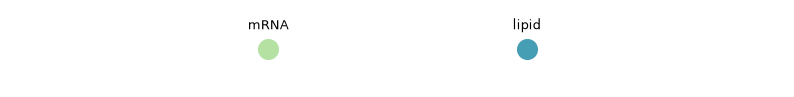

In [87]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.15, 0.95, 10))

compound_colors = {
        "mRNA": cmap[6],
        "lipid": cmap[8],
    } 
fig, ax = plt.subplots(figsize=(10, 1))
for i, (c, color) in enumerate(compound_colors.items()):
    ax.scatter(i, 0, color=color, s=200)
    ax.text(i, 0.5, str(c), ha='center', fontsize=9)
ax.set_xlim(-1, len(compound_colors))
ax.set_ylim(-1, 1)
ax.axis("off")

plt.show()

In [88]:
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 25,
    "axes.titlesize": 20,
    "xtick.labelsize": 15,
    "legend.fontsize": 25,
    "figure.titlesize": 20,
})

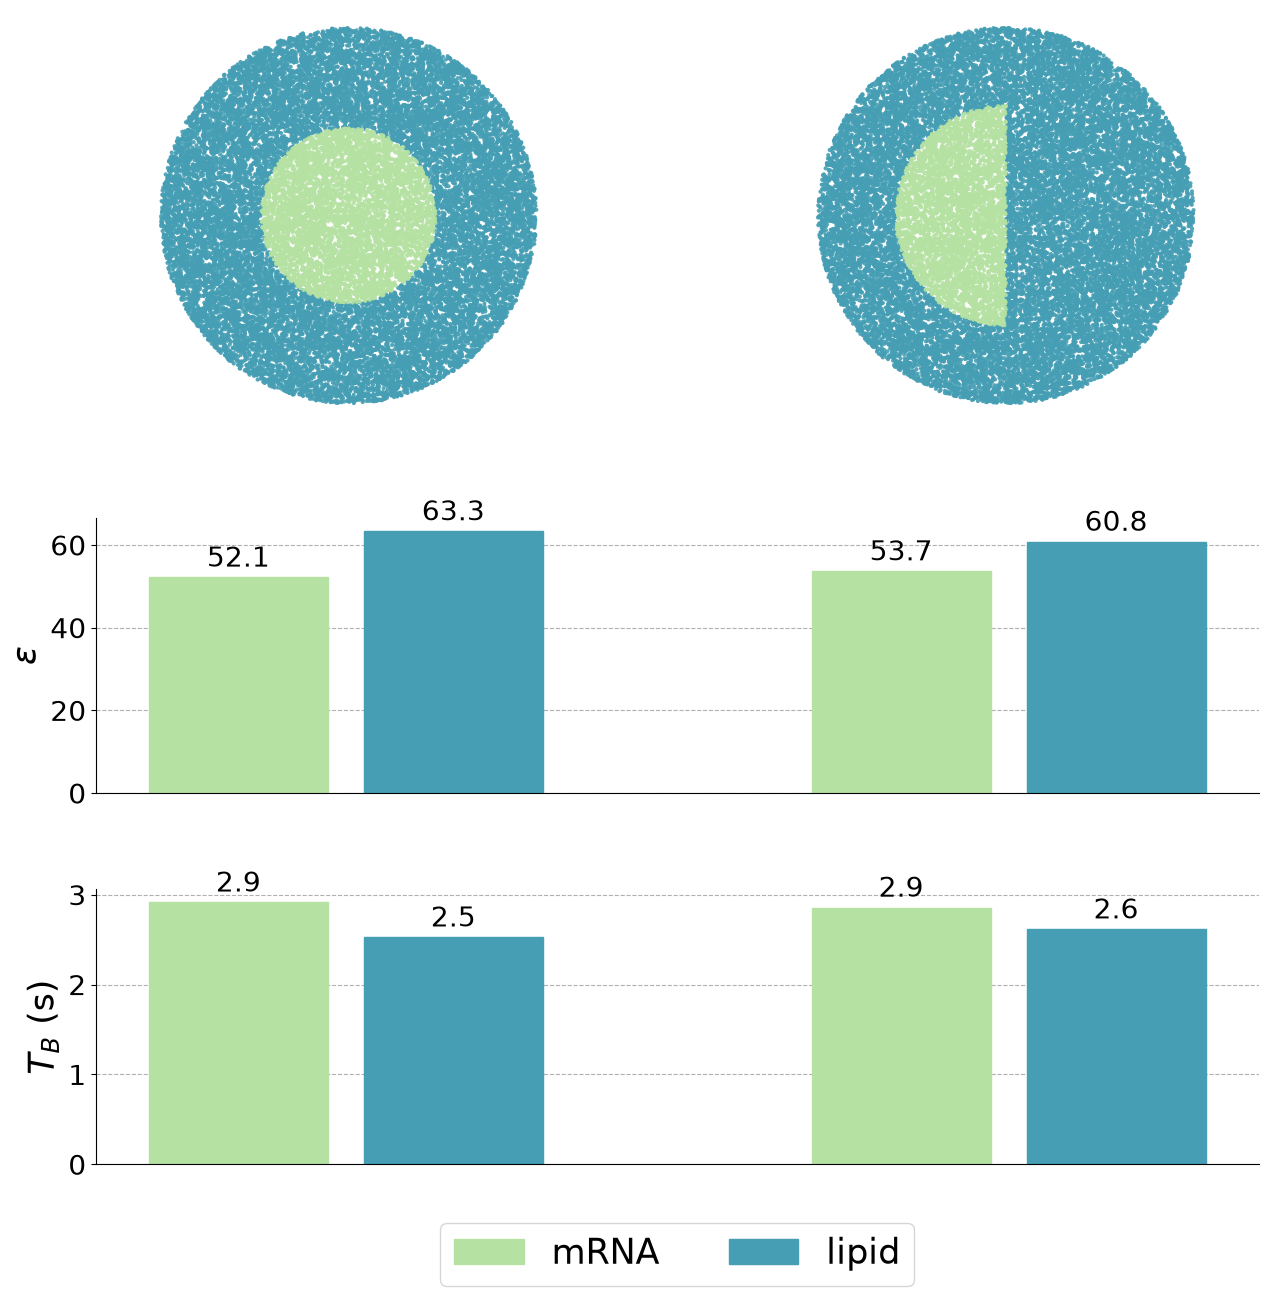

In [90]:
fig = plt.figure(figsize=(15, 15))
N = len(id_models)
gs = fig.add_gridspec(3, N, height_ratios=[1.5, 1, 1])

axes = {}
for n in range(N):
    base = n
    axes[f"lnp_{n}"] = fig.add_subplot(gs[0, base])
axes[f"epsilon"] = fig.add_subplot(gs[1, :])
axes[f"TB"] = fig.add_subplot(gs[2, :])

for n, (name, model_points) in enumerate(models_points.groupby("model")):
    ax = axes[f"lnp_{n}"]
    for c, compound_points in model_points.groupby("compound"):
        ax.scatter(compound_points["x"], compound_points["y"],s=9, alpha=0.9, edgecolors='none', color = compound_colors[c])
        ax.set_aspect("equal")
        ax.axis('off')

epsilon = models_result["epsilon_d1"].unstack().reindex(columns=compounds)

ax1 = axes["epsilon"]
ax1.set_ylabel(r"$\varepsilon$")
ax1.grouped_bar(epsilon, bar_spacing=0.2)
ax1.set_xticks([])

for container, compound in zip(ax1.containers, epsilon.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])    
    labels = [f"{v:.1f}" for v in epsilon[compound]]
    ax1.bar_label(container, labels=labels, padding=3)

TB = models_result["TB_s"].unstack().reindex(columns=compounds)

ax2 = axes["TB"]
ax2.set_ylabel(r"$T_B$ (s)")
ax2.grouped_bar(TB, bar_spacing=0.2)
ax2.set_xticks([])

for container, compound in zip(ax2.containers, TB.columns):
    for bar in container:
        bar.set_color(compound_colors[compound])
    labels = [f"{v:.1f}" for v in TB[compound]]
    ax2.bar_label(container, labels=labels, padding=3)

ax2.legend(ncol=len(compounds),loc="upper center", bbox_to_anchor=(0.5, -0.15))
        
for ax in (ax1, ax2):
    ax.grid(True, axis="y", linestyle="--")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.subplots_adjust(hspace=0.3, wspace = 0.3)
plt.savefig("half-shell.png", dpi=150, bbox_inches="tight")
plt.show()